All neccessary packages and directories

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime
import os
import sys
import getpass as _getpass

# Set Username
user_name=_getpass.getuser()

if user_name=='fabioballoni':

    sys.path.append('/Users/%s/Development/repos/risk/risk_pylibrary/'%user_name)
    sys.path.append('/Users/%s/Development/repos/risk/'%user_name)
    
elif user_name=='victoriadobryashkina':

    sys.path.append('/Users/%s/Documents/Coding/repos/risk_pylibrary'%user_name)
    sys.path.append('/Users/%s/Documents/Coding/repos'%user_name)


from tools.snowflake_db import db_connection as db
from risk_pylibrary.risk_analytics import risk_engines as re

np.random.seed(17)


     ------------------------------------------------------------
               Risk @ Trade Republic Bank GmbH
     ------------------------------------------------------------
      Node: fabioballoni	User: fabioballoni
      Python version 3.12.8 (v3.12.8:2dc476bcb91, Dec  3 2024, 14:43:19) [Clang 13.0.0 (clang-1300.0.29.30)]
      pandas: 2.2.3	numpy: 2.2.3
      Kernel started 2025-04-29 14:39
     ------------------------------------------------------------


**1. Investigate Existent Stressed VaR Function**

Set up all data. Create random sets

In [ ]:

#random returns
rets=pd.DataFrame(np.random.randn(500, 5) * 0.01)

#random weights 
N = rets.shape[1]
wgts = np.random.dirichlet(np.ones(N), size=1)

Get Portfolio Data

In [ ]:
from risk_pylibrary.projects.caracalla import caracalla_portfolio as c_port
from datetime import date

accounts=['tiberius','caligula','caracalla','trajan']
value_date=date(2025,3,31)

out=pd.DataFrame()
for account in accounts:
    out_dict_tmp = c_port.get_caracalla_portfolio(calc_rf_port=False,calc_risk=False,calc_pnl_report=False,value_date=value_date,risk_engines={},rf_mapping_new=True,
                                                force_rf=True, new_pf_engine=True, live_trading=False, account=account)
    
    tmp_rf=out_dict_tmp['rf_portfolio']
    tmp_rf=tmp_rf.reset_index()[['risk_factor','weight']].groupby('risk_factor').sum()
    tmp_rf.columns=[account]
    out=pd.concat([out,tmp_rf],axis=1)

    rets=
    

array([[0.18850937, 0.37376957, 0.0998637 , 0.2345431 , 0.10331426]])

Calculate Stressed VaR

In [ ]:
stressedVaR = re.stressed_vaR(rets_orig=rets,wgts=wgts, engine='hs')


     ------------------------------------------------------------
               Portfolio Stressed VaR Calculation
     ------------------------------------------------------------
      Model: 
			hs

      Model Inputs:
 			window: 250
			qtls: [0.05, 0.01, 0.001]
			holding_period: 1
			rescale: 1000
			decay: 1
			ftol: 1e-06
			max_iter: 150
			fhs: False
			distr: Normal
			garch_engine: gjr
			verbose: True

      Series Start and End:
 			Start 0, End 499
     ------------------------------------------------------------

Initializing Historical Simulation Model for Value at Risk Calculation with 499 windows
			 Calculated 250 windows


In [ ]:
stressedVaR.head()

,var950_1d,cvar950_1d,var990_1d,cvar990_1d,var999_1d,cvar999_1d
250,0.007482,0.009629,0.011045,0.012042,0.012571,0.012716
251,0.007482,0.009629,0.011045,0.012042,0.012571,0.012716
252,0.007482,0.009629,0.011045,0.012042,0.012571,0.012716
253,0.007482,0.009629,0.011045,0.012042,0.012571,0.012716
254,0.007482,0.009629,0.011045,0.012042,0.012571,0.012716


Plot the results

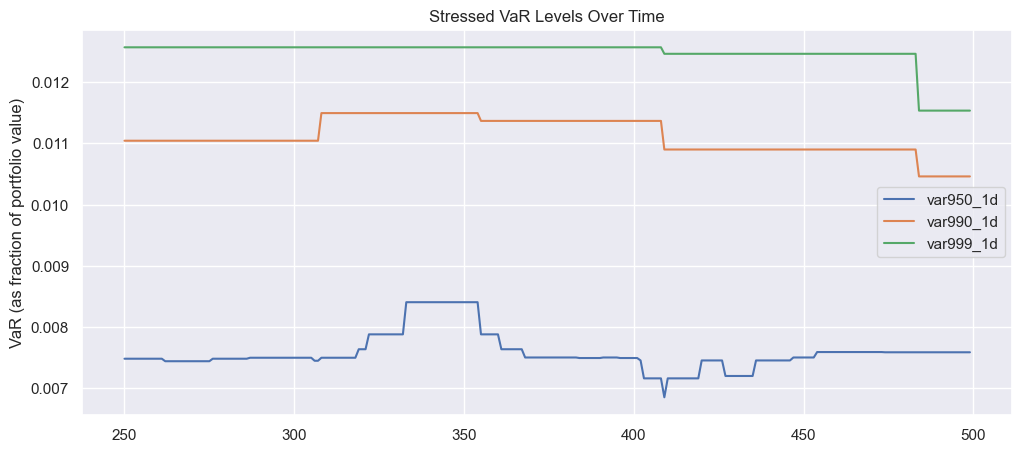

In [ ]:
out = stressedVaR 

out[['var950_1d', 'var990_1d', 'var999_1d']].plot(figsize=(12, 5), title='Stressed VaR Levels Over Time')
plt.ylabel('VaR (as fraction of portfolio value)')
plt.grid(True)
plt.show()


Evaluate the results. 
With 1% volativily of returns (rets=pd.DataFrame(np.random.randn(500, 5) * 0.01)) the 99.9% VaR is expected to be between 0.01 and 0.02, which tells that the above results are legitimate.

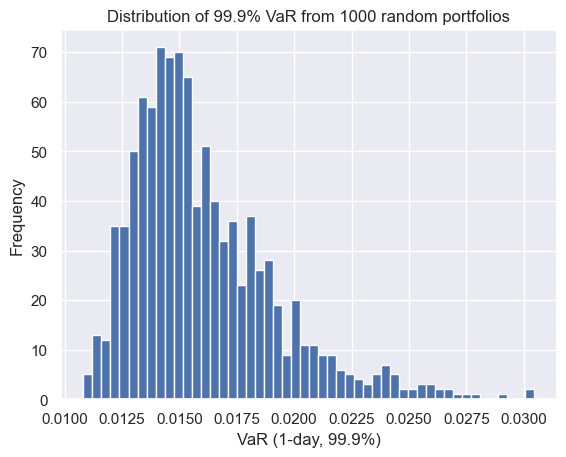

In [25]:
vaRs = []
for _ in range(1000):
    wgts = np.random.dirichlet(np.ones(5), size=1)
    pf_returns = rets @ wgts.T
    vaRs.append(-np.quantile(pf_returns, 0.001))

import matplotlib.pyplot as plt
plt.hist(vaRs, bins=50)
plt.title("Distribution of 99.9% VaR from 1000 random portfolios")
plt.xlabel("VaR (1-day, 99.9%)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


**2. Portfolio Wide Rolling VaR for Stressed Periods**

Now lets take the stress scenarios

In [3]:
sql_query_scenarios= '''
select * 
from TEAMS_PRD.RISK_DATA_SENSITIVE.RISK_STRESS_SCENARIO_DEFINITIONS
'''
scenarios = db.run_query(query=sql_query_scenarios)


Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJPc9owEMW%2Fikc925LBFNAAGTcMhTahNEBnmpuwF6JBlhytjEk%2BfWX%2BdNJDcuhNI73d39O%2BHdwcCxUcwKI0ekjiiJEAdGZyqXdDsl5Nwh4J0AmdC2U0DMkLILkZDVAUquRp5Z70AzxXgC7wjTTy5mFIKqu5ESiRa1EAcpfxZXp%2Fx1sR4wIRrPM4cinJUXrWk3Mlp7Su66huR8buaIsxRlmfelUj%2BUTeIMqPGaU1zmRGXUuO%2Fk%2FvIGLKkgbhFZ6wuBR%2Bkfo8go8om7MI%2BXS1WoSLH8sVCdLr726NxqoAuwR7kBmsH%2B7OBtA7%2BHr%2FudfudiOowgy0s0KFcYTa1Fsl9pCZoqycbxz5E91CTpXZST%2Bu2XhIyr3MO7t1Aeu5MY%2Fzabb4ravngzDpNpnKSRnXmKRK5N%2BXBfyc9zIS%2FLqG22rCnSFWMNNNpM5fsVYnZEkYJyvW5wnjcSdqt%2FuPJBj7SKUW7lR59e2d5mChrDZKZpHZO3GyKMqS%2FnVP4biPe69mc2zvEb9NDsck7lJEQ5vcyHl1%2BMmGHf3HQAb0bYPLIs59NrPxwnhbL8HE2EK496OLo%2Fh0I%2FNwe5JyKIRUaZ5bQPQRKmXqWwvC%2BX13tgJCR2

/Users/victoriadobryashkina/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:181: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, CF.sf_conn)


Add Excel for SF Table update.

-> with inserted “shock_startdate”

-> with the shock_length you can address the “shock_enddate” via code.

In [4]:
os.getcwd()
xl_scenarios =pd.read_excel (r'/Users/victoriadobryashkina/Downloads/20250411_UpdateStressScenarioTable.xlsx')


In [5]:
xl_scenarios

,Unnamed: 0,code,name,scenario_type,lookback_horizon,shock_length,shock_startdate,stress_scenario_parameter,stress_scenario_description
0,0,stress_covid19,MR - Covid19 Shock,Historical,1250,20,2020-02-26,sp500 -25%|dax -30%|nikkei225 -30%|YIELD_US_10...,"20 day shock period (S&P500 -25%, DAX -30%, Ni..."
1,1,stress_ftxctrash,MR - Cryptocurrency FTX Crash 2022,Historical,1250,5,2022-11-06,btc_eur -25%|eth_eur -25%,"1 day shock period (BTC Shock Down -25%, ETH S..."
2,2,stress_usdcrash,MR - USD Crash,Hypothetical,1250,10,2023-07-01,fx_eurusd -10%,5 day shock period (USD/EUR Shock Down -10%)
3,3,stress_fincrisis,MR - Financial Crisis 08/09,Historical,1250,125,2008-09-15,YIELD_US_10Y 350bps|YIELD_US_3Y 150bps|YIELD_D...,250 day shock period (Gov. Short Rates Shock D...
4,4,stress_emudebt,MR - European Debt Crisis 2012,Historical,1250,90,2012-01-15,YIELD_IT_3Y -300bps|YIELD_IT_10Y -600bps|YIELD...,90 day shock period (Gov. Short Rates (exGerma...
5,5,stress_globalinflation,MR - Global Rise Inflation,Hypothetical,1250,120,2022-03-01,YIELD_IT_3Y -200bps|YIELD_IT_10Y -400bps|YIELD...,"120 day shock period (US CPI Shock Up 6%, EU C..."


Create dummy returns data, preserve the patched typeof data. 
The series, to fit stressed_vaR function have to be on the portfolio level in the end.

In [ ]:
import pandas_patched as pp

#Set uniform weights for single assets
wgts = np.full((1, 8), 1/8)

# Create date range and dummy data
date_range = pd.date_range(start="2006-01-01", end="2024-01-01", freq="B") #Business Days
indices = ['sp500', 'dax', 'nikkei225', 'btc_eur', 'eth_eur', 'fx_eurusd', 'YIELD_US_10Y', 'YIELD_US_3Y']
dummy_data = np.random.normal(loc=0, scale=0.01, size=(len(date_range), len(indices)))

# Create portfolio returns
dummy_raw = pd.DataFrame(dummy_data, index=date_range, columns=indices)
dummy_patched = dummy_raw.portfolio_rets(wgts)  # shape = [# dates, 1], column = 'pf'


In [191]:
dummy_patched.head()

,pf
2006-01-02,0.003626
2006-01-03,0.001682
2006-01-04,0.002406
2006-01-05,0.000020
2006-01-06,0.001834


Redefine weights, because now we have portfolio level, not single asset

In [192]:
wgts = np.array([[1.0]])


Define rolling VaR

In [ ]:
def stressed_var_rolling(
    rets_orig,
    wgts=None,  # Optional 
    engine='hs',
    fmt_engine={},
    threshold=0.01,
    verbose=False
):
    import pandas as pd
    from risk_pylibrary.risk_analytics import risk_engines as re

    results = []
    window = fmt_engine.get('window', 250)

    for i in range(window, len(rets_orig)):
        rets_window = rets_orig.iloc[i - window:i + 1]
        date = rets_orig.index[i]

        try:
            result = re.stressed_vaR(
                rets_orig=rets_window,
                wgts=wgts, 
                engine=engine,
                fmt_engine=fmt_engine,
                verbose=verbose
            )
        except Exception as e:
            print(f"[!] Error calculating VaR on {date.date()} with engine {engine}: {e}")
            continue

        row = {'date': date}
        for col in result.columns:
            value = result.loc[result.index[-1], col]
            row[col] = value
            if col.startswith('var'):
                level = col.replace("var", "").replace("_1d", "")
                row[f"breach{level}"] = value > threshold

        results.append(row)

    return pd.DataFrame(results).set_index('date')


Wrapper to run across all scenarios in xl_scenarios

In [ ]:
def run_all_scenario_svar(rets_full, wgts, scenario_df, fmt_engine_base, threshold=0.01):
    """
    Runs rolling stressed_vaR for each scenario and engine type.
    Supports any engine implemented in the original stressed_vaR().
    """
    out = {}

    scenario_type_map = {
        'Historical': 'hs',
        'Hypothetical': 'gjr'  # extend as needed!! in the scenarios only those two, might be more
    }

    for _, row in scenario_df.iterrows():
        code = row['code']
        start_date = pd.to_datetime(row['shock_startdate'])
        length = int(row['shock_length'])
        scenario_type = row['scenario_type']
        engine = scenario_type_map.get(scenario_type, 'hs')

        window = fmt_engine_base.get('window', 250)
        rets_window = rets_full.loc[start_date:]
        rets_window = rets_window.iloc[:length + window]

        if len(rets_window) < length + window:
            print(f"[!] Skipping {code}: not enough data for {window + length} days from {start_date.date()}")
            continue

        print(f"Running rolling stressed_vaR for {code} ({scenario_type}) using engine: {engine}")

        result = stressed_var_rolling(
            rets_orig=rets_window,
            wgts=wgts,
            engine=engine,
            fmt_engine={**fmt_engine_base, 'window': window},
            threshold=threshold,
            verbose=False
        )

        out[code] = result

    return out



Take 99% and 99.9% 1-day VaR

In [195]:
results = run_all_scenario_svar(
    rets_full=dummy_patched,  # already contains 'pf'
    wgts=wgts,
    scenario_df=xl_scenarios,
    fmt_engine_base={'qtls': [0.01,0.001], 'holding_period': 1, 'window': 250},
    threshold=0.01
)

Running rolling stressed_vaR for stress_covid19 (Historical) using engine: hs

     ------------------------------------------------------------
               Portfolio Stressed VaR Calculation
     ------------------------------------------------------------
      Model: 
			hs

      Model Inputs:
 			qtls: [0.01, 0.001]
			holding_period: 1
			window: 250
			decay: 0.94
			distr: norm
			verbose: True

      Series Start and End:
 			Start 2020-02-26 00:00:00, End 2021-02-10 00:00:00
     ------------------------------------------------------------

     ------------------------------------------------------------
               Portfolio Stressed VaR Calculation
     ------------------------------------------------------------
      Model: 
			hs

      Model Inputs:
 			qtls: [0.01, 0.001]
			holding_period: 1
			window: 250
			decay: 0.94
			distr: norm
			verbose: True

      Series Start and End:
 			Start 2020-02-27 00:00:00, End 2021-02-11 00:00:00
     ---------------------

In [190]:
type(results)

dict

Define max VaR per scenario

In [151]:
def max_var_per_scenario(results_dict, quantile=0.01):
    """
    Extracts the maximum VaR value for each scenario from the results dictionary.

    Parameters:
        results_dict : dict
            Dictionary with scenario name as key and result DataFrame as value.
        quantile : float
            Quantile level used in the VaR column (e.g. 0.01 for 99%).

    Returns:
        DataFrame with max VaR value per scenario.
    """
    var_col = f'var{int((1 - quantile) * 1000)}_1d'
    summary = []

    for scenario, df in results_dict.items():
        if var_col in df.columns and not df.empty:
            max_var = df[var_col].max()
            summary.append({'scenario': scenario, 'max_var': round(max_var, 6)})
        else:
            summary.append({'scenario': scenario, 'max_var': None})

    return pd.DataFrame(summary).sort_values(by='max_var', ascending=False)


In [173]:
max_var_summary = max_var_per_scenario(results, quantile=0.001)
print(max_var_summary)


                 scenario   max_var
4  stress_globalinflation  0.010866
2        stress_fincrisis  0.010160
1        stress_ftxctrash  0.009375
0          stress_covid19  0.008963
3          stress_emudebt  0.008302


Define flattening results function, dict to dataframe

In [ ]:
def flatten_results(results_dict):
    dfs = []
    for scenario, df in results_dict.items():
        if not df.empty:
            df_copy = df.copy()
            df_copy["scenario"] = scenario
            dfs.append(df_copy)
    return pd.concat(dfs).reset_index()


In [ ]:
# Flatten the dict of DataFrames
all_results_df = flatten_results(results)

# Export to Excel to make a pivot or cross-check
all_results_df.to_excel('/Users/victoriadobryashkina/Downloads/stressed_var_all_scenarios.xlsx', index=False)


Define breaches counter function

In [164]:
def count_breaches_flat(results_df, quantile=0.01):
    """
    Counts how many times the rolling VaR breached the threshold per scenario from a flat DataFrame.

    Parameters:
    - results_df: Flattened DataFrame (with 'scenario' column)
    - quantile: VaR quantile used (e.g. 0.01 for 99%)

    Returns:
    - DataFrame with scenario name, breach count, and total days
    """
    col_flag = f'breach{int(1000 * (1 - quantile))}'

    if col_flag not in results_df.columns:
        raise ValueError(f"Breach column '{col_flag}' not found in the DataFrame.")

    summary = (
        results_df
        .groupby('scenario')
        .agg(
            breach_count=(col_flag, 'sum'),
            total_days=(col_flag, 'count')
        )
        .reset_index()
    )
    summary['breach_rate'] = (summary['breach_count'] / summary['total_days'] * 100).round(2)

    return summary.sort_values(by='breach_count', ascending=False)


Define a function to check which quantiles were in the sample (which we defined above)

In [169]:
def extract_quantiles(results_dict):
    """
    Scans all scenario result DataFrames to find which VaR quantile levels were calculated.
    Returns a dictionary: scenario → list of quantiles.
    """
    quantile_map = {}

    for scenario, df in results_dict.items():
        quantiles = set()
        for col in df.columns:
            if col.startswith("var") and "_1d" in col:
                level = col.replace("var", "").replace("_1d", "")
                try:
                    quantile = round(1 - int(level) / 1000, 4)
                    quantiles.add(quantile)
                except:
                    continue
        quantile_map[scenario] = sorted(quantiles)

    return quantile_map


In [196]:
extract_quantiles(results)


{'stress_covid19': [0.001, 0.01],
 'stress_ftxctrash': [0.001, 0.01],
 'stress_fincrisis': [0.001, 0.01],
 'stress_emudebt': [0.001, 0.01],
 'stress_globalinflation': [0.001, 0.01]}

In [175]:
breach_summary = count_breaches(results, quantile=0.001)
print(breach_summary)


                 scenario  breach_count  total_days  breach_rate
4  stress_globalinflation           114         120         95.0
2        stress_fincrisis            52         125         41.6
0          stress_covid19             0          20          0.0
1        stress_ftxctrash             0           5          0.0
3          stress_emudebt             0          90          0.0
